In [2]:
import os
import json
import time
import math
import random
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_SPLITS = PROJECT_ROOT / "data" / "splits"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
LOGS = OUTPUTS / "logs"

for p in [DATA_RAW, DATA_PROCESSED, DATA_SPLITS, OUTPUTS, FIGURES, TABLES, LOGS]:
    p.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(DATA_RAW)

C:\Users\User\comp6001_assignment1
C:\Users\User\comp6001_assignment1\data\raw


In [4]:
GOPRO_DIR = DATA_RAW / "gopro"
COCOBLUR_DIR = DATA_RAW / "cocoblur"
COCO_DIR = DATA_RAW / "coco2017"

print("GoPro exists:", GOPRO_DIR.exists())
print("COCOBlur exists:", COCOBLUR_DIR.exists())
print("COCO exists:", COCO_DIR.exists())

GoPro exists: True
COCOBlur exists: True
COCO exists: True


In [5]:
def list_files(root, exts=(".png", ".jpg", ".jpeg", ".bmp")):
    root = Path(root)
    files = []
    for ext in exts:
        files.extend(root.rglob(f"*{ext}"))
        files.extend(root.rglob(f"*{ext.upper()}"))
    return sorted(set(files))

def show_tree(root, max_depth=3, max_entries=8):
    root = Path(root)
    for path, dirs, files in os.walk(root):
        rel = Path(path).relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        indent = "  " * depth
        print(f"{indent}{rel if str(rel) != '.' else root.name}/")
        for f in files[:max_entries]:
            print(f"{indent}  {f}")

In [6]:
if GOPRO_DIR.exists():
    show_tree(GOPRO_DIR, max_depth=3, max_entries=5)

gopro/
  blur/
    blur\images/
      000001.png
      000002.png
      000003.png
      000004.png
      000005.png
  sharp/
    sharp\images/
      000001.png
      000002.png
      000003.png
      000004.png
      000005.png


In [7]:
if COCOBLUR_DIR.exists():
    show_tree(COCOBLUR_DIR, max_depth=3, max_entries=5)

cocoblur/
  val2017/
    000000000139.jpg
    000000000285.jpg
    000000000632.jpg
    000000000724.jpg
    000000000776.jpg


In [8]:
if COCO_DIR.exists():
    show_tree(COCO_DIR, max_depth=3, max_entries=5)

coco2017/
  annotations/
    captions_train2017.json
    captions_val2017.json
    instances_train2017.json
    instances_val2017.json
    person_keypoints_train2017.json
  test2017/
    000000000001.jpg
    000000000016.jpg
    000000000019.jpg
    000000000057.jpg
    000000000063.jpg
  train2017/
    000000000009.jpg
    000000000025.jpg
    000000000030.jpg
    000000000034.jpg
    000000000036.jpg
  val2017/
    000000000139.jpg
    000000000285.jpg
    000000000632.jpg
    000000000724.jpg
    000000000776.jpg


In [9]:
def read_rgb(path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not read {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read {path}")
    return img

def laplacian_variance(path):
    gray = read_gray(path)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def image_shape(path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    h, w = img.shape[:2]
    return h, w

In [10]:
def collect_keyword_images(base_dir, keyword):
    base_dir = Path(base_dir)
    candidates = []
    for p in list_files(base_dir):
        if keyword.lower() in str(p.parent).lower():
            candidates.append(p)
    return candidates

def pair_by_filename(blur_paths, sharp_paths):
    blur_map = {p.name: p for p in blur_paths}
    sharp_map = {p.name: p for p in sharp_paths}
    common = sorted(set(blur_map.keys()) & set(sharp_map.keys()))
    rows = []
    for name in common:
        rows.append({
            "filename": name,
            "blur_path": str(blur_map[name]),
            "sharp_path": str(sharp_map[name]),
            "blur_shape": image_shape(blur_map[name]),
            "sharp_shape": image_shape(sharp_map[name]),
            "blur_lap_var": laplacian_variance(blur_map[name]),
            "sharp_lap_var": laplacian_variance(sharp_map[name]),
        })
    return pd.DataFrame(rows)

In [11]:
gopro_blur_paths = collect_keyword_images(GOPRO_DIR, "blur") if GOPRO_DIR.exists() else []
gopro_sharp_paths = collect_keyword_images(GOPRO_DIR, "sharp") if GOPRO_DIR.exists() else []

print("GoPro blur images:", len(gopro_blur_paths))
print("GoPro sharp images:", len(gopro_sharp_paths))

gopro_pairs_df = pair_by_filename(gopro_blur_paths, gopro_sharp_paths) if len(gopro_blur_paths) and len(gopro_sharp_paths) else pd.DataFrame()
print("Matched GoPro pairs:", len(gopro_pairs_df))
gopro_pairs_df.head()

GoPro blur images: 1029
GoPro sharp images: 1029
Matched GoPro pairs: 1029


,filename,blur_path,sharp_path,blur_shape,sharp_shape,blur_lap_var,sharp_lap_var
0,000001.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",13.613243,185.186727
1,000002.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",44.505477,186.324475
2,000003.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",37.046103,197.533175
3,000004.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",32.943472,190.854369
4,000005.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",25.160059,193.846921


In [12]:
if len(gopro_pairs_df):
    gopro_pairs_df["blur_ratio"] = gopro_pairs_df["blur_lap_var"] / (gopro_pairs_df["sharp_lap_var"] + 1e-8)
    gopro_pairs_df["blur_level"] = pd.qcut(
        gopro_pairs_df["blur_lap_var"],
        q=3,
        labels=["high_blur", "medium_blur", "low_blur"]
    )
    gopro_pairs_df.head()

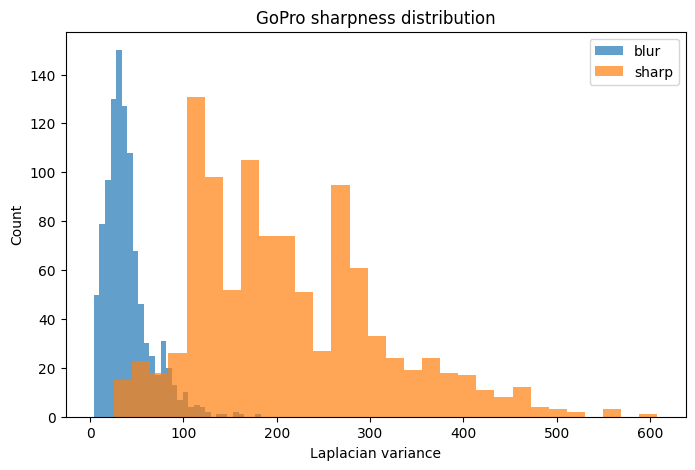

In [13]:
if len(gopro_pairs_df):
    plt.figure(figsize=(8, 5))
    plt.hist(gopro_pairs_df["blur_lap_var"], bins=30, alpha=0.7, label="blur")
    plt.hist(gopro_pairs_df["sharp_lap_var"], bins=30, alpha=0.7, label="sharp")
    plt.xlabel("Laplacian variance")
    plt.ylabel("Count")
    plt.title("GoPro sharpness distribution")
    plt.legend()
    plt.show()

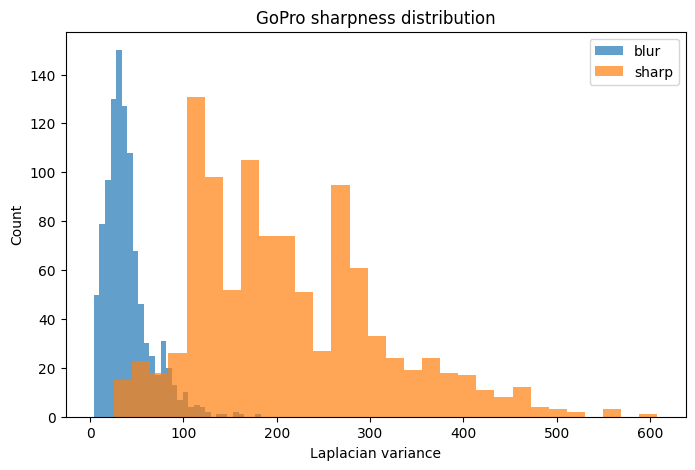

In [14]:
if len(gopro_pairs_df):
    plt.figure(figsize=(8, 5))
    plt.hist(gopro_pairs_df["blur_lap_var"], bins=30, alpha=0.7, label="blur")
    plt.hist(gopro_pairs_df["sharp_lap_var"], bins=30, alpha=0.7, label="sharp")
    plt.xlabel("Laplacian variance")
    plt.ylabel("Count")
    plt.title("GoPro sharpness distribution")
    plt.legend()
    plt.show()

In [15]:
COCO_VAL_IMAGES = COCO_DIR / "val2017"
COCO_TRAIN_IMAGES = COCO_DIR / "train2017"
COCO_ANNOTATIONS = COCO_DIR / "annotations"
COCOBLUR_VAL_IMAGES = COCOBLUR_DIR / "val2017"

print(COCO_VAL_IMAGES.exists(), COCO_TRAIN_IMAGES.exists(), COCO_ANNOTATIONS.exists(), COCOBLUR_VAL_IMAGES.exists())

True True True True


In [16]:
def collect_by_stem(image_dir):
    paths = list_files(image_dir)
    return {p.stem: p for p in paths}

coco_val_map = collect_by_stem(COCO_VAL_IMAGES) if COCO_VAL_IMAGES.exists() else {}
cocoblur_val_map = collect_by_stem(COCOBLUR_VAL_IMAGES) if COCOBLUR_VAL_IMAGES.exists() else {}

common_val_ids = sorted(set(coco_val_map.keys()) & set(cocoblur_val_map.keys()))

print("COCO val images:", len(coco_val_map))
print("COCOBlur val images:", len(cocoblur_val_map))
print("Matched sharp-blur val pairs:", len(common_val_ids))
print(common_val_ids[:5])

COCO val images: 5000
COCOBlur val images: 5000
Matched sharp-blur val pairs: 5000
['000000000139', '000000000285', '000000000632', '000000000724', '000000000776']


In [17]:
coco_pairs_rows = []
for image_id in common_val_ids:
    sharp_path = coco_val_map[image_id]
    blur_path = cocoblur_val_map[image_id]
    coco_pairs_rows.append({
        "image_id": image_id,
        "sharp_path": str(sharp_path),
        "blur_path": str(blur_path),
        "sharp_shape": image_shape(sharp_path),
        "blur_shape": image_shape(blur_path),
        "sharp_lap_var": laplacian_variance(sharp_path),
        "blur_lap_var": laplacian_variance(blur_path),
    })

coco_pairs_df = pd.DataFrame(coco_pairs_rows)
print(len(coco_pairs_df))
coco_pairs_df.head()

5000


,image_id,sharp_path,blur_path,sharp_shape,blur_shape,sharp_lap_var,blur_lap_var
0,000000000139,C:\Users\User\comp6001_assignment1\data\raw\co...,C:\Users\User\comp6001_assignment1\data\raw\co...,"(426, 640)","(426, 640)",854.226167,854.226167
1,000000000285,C:\Users\User\comp6001_assignment1\data\raw\co...,C:\Users\User\comp6001_assignment1\data\raw\co...,"(640, 586)","(640, 586)",4351.070365,4351.070365
2,000000000632,C:\Users\User\comp6001_assignment1\data\raw\co...,C:\Users\User\comp6001_assignment1\data\raw\co...,"(483, 640)","(483, 640)",4177.362686,4177.362686
3,000000000724,C:\Users\User\comp6001_assignment1\data\raw\co...,C:\Users\User\comp6001_assignment1\data\raw\co...,"(500, 375)","(500, 375)",2844.920072,2844.920072
4,000000000776,C:\Users\User\comp6001_assignment1\data\raw\co...,C:\Users\User\comp6001_assignment1\data\raw\co...,"(640, 428)","(640, 428)",4690.731953,4690.731953


In [18]:
if len(coco_pairs_df):
    coco_pairs_df["blur_level"] = pd.qcut(
        coco_pairs_df["blur_lap_var"],
        q=3,
        labels=["high_blur", "medium_blur", "low_blur"]
    )
    coco_pairs_df["blur_ratio"] = coco_pairs_df["blur_lap_var"] / (coco_pairs_df["sharp_lap_var"] + 1e-8)
    coco_pairs_df.head()

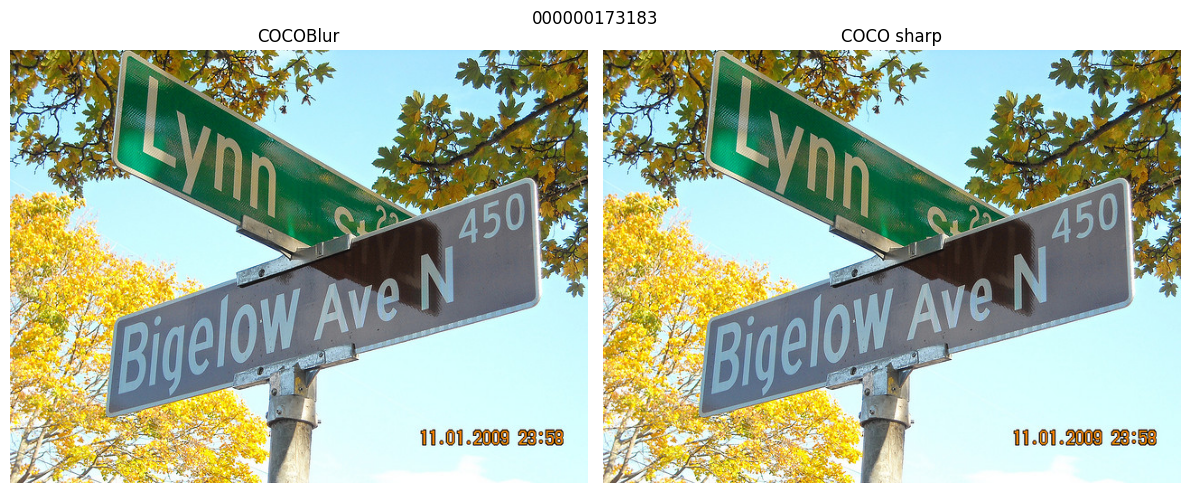

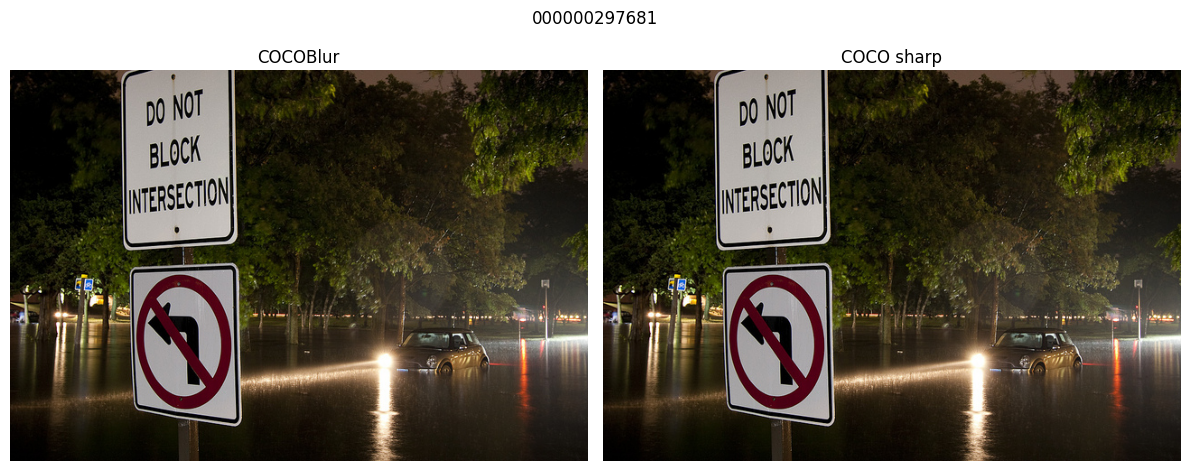

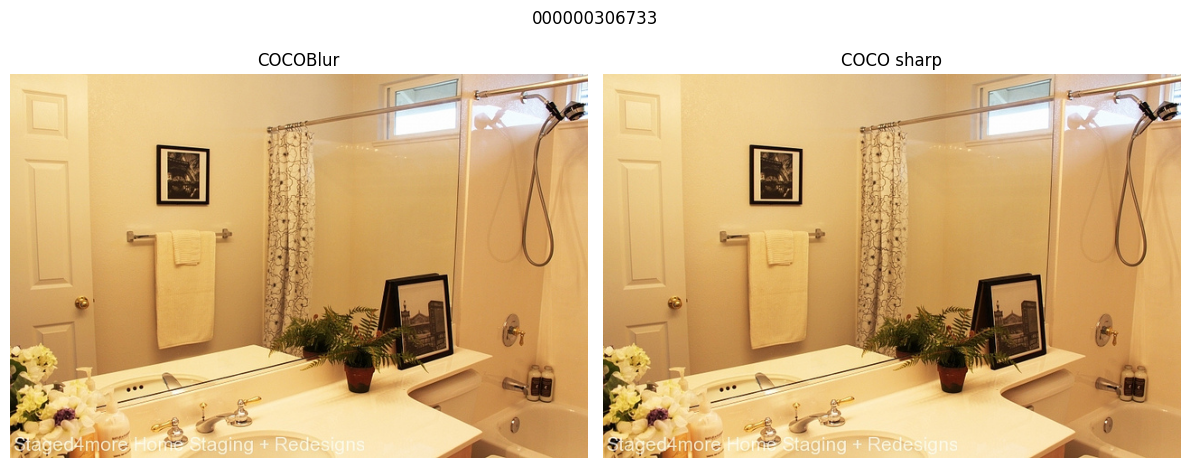

In [19]:
if len(coco_pairs_df):
    sample_df = coco_pairs_df.sample(min(3, len(coco_pairs_df)), random_state=SEED)
    for _, row in sample_df.iterrows():
        blur_img = read_rgb(row["blur_path"])
        sharp_img = read_rgb(row["sharp_path"])

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(blur_img)
        axes[0].set_title("COCOBlur")
        axes[0].axis("off")

        axes[1].imshow(sharp_img)
        axes[1].set_title("COCO sharp")
        axes[1].axis("off")

        plt.suptitle(row["image_id"])
        plt.tight_layout()
        plt.show()

In [20]:
gopro_pairs_path = DATA_PROCESSED / "gopro_pairs_metadata.csv"
coco_pairs_path = DATA_PROCESSED / "coco_val_blur_pairs_metadata.csv"

if len(gopro_pairs_df):
    gopro_pairs_df.to_csv(gopro_pairs_path, index=False)

if len(coco_pairs_df):
    coco_pairs_df.to_csv(coco_pairs_path, index=False)

print(gopro_pairs_path)
print(coco_pairs_path)

C:\Users\User\comp6001_assignment1\data\processed\gopro_pairs_metadata.csv
C:\Users\User\comp6001_assignment1\data\processed\coco_val_blur_pairs_metadata.csv


In [21]:
summary = {
    "gopro_pairs": int(len(gopro_pairs_df)),
    "coco_val_pairs": int(len(coco_pairs_df)),
    "gopro_blur_levels": gopro_pairs_df["blur_level"].value_counts().to_dict() if len(gopro_pairs_df) else {},
    "coco_blur_levels": coco_pairs_df["blur_level"].value_counts().to_dict() if len(coco_pairs_df) else {},
}

summary

{'gopro_pairs': 1029,
 'coco_val_pairs': 5000,
 'gopro_blur_levels': {'high_blur': 343, 'medium_blur': 343, 'low_blur': 343},
 'coco_blur_levels': {'high_blur': 1667,
  'low_blur': 1667,
  'medium_blur': 1666}}

In [22]:
with open(LOGS / "data_setup_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(LOGS / "data_setup_summary.json")

C:\Users\User\comp6001_assignment1\outputs\logs\data_setup_summary.json


In [23]:
gopro_blur_counts = gopro_pairs_df["blur_level"].value_counts().reset_index()
gopro_blur_counts.columns = ["blur_level", "count"]
coco_blur_counts = coco_pairs_df["blur_level"].value_counts().reset_index()
coco_blur_counts.columns = ["blur_level", "count"]
display(gopro_blur_counts)
display(coco_blur_counts)

,blur_level,count
0,high_blur,343
1,medium_blur,343
2,low_blur,343


,blur_level,count
0,high_blur,1667
1,low_blur,1667
2,medium_blur,1666


In [24]:
annotations_path = COCO_DIR / "annotations" / "instances_val2017.json"

with open(annotations_path, "r") as f:
    coco = json.load(f)

images_df = pd.DataFrame(coco["images"])
annotations_df = pd.DataFrame(coco["annotations"])
categories_df = pd.DataFrame(coco["categories"])

id_to_name = dict(zip(categories_df["id"], categories_df["name"]))

sample_image_ids = set(int(x) for x in coco_pairs_df["image_id"].tolist())
subset_annotations = annotations_df[annotations_df["image_id"].isin(sample_image_ids)].copy()
subset_annotations["class_name"] = subset_annotations["category_id"].map(id_to_name)

class_counts = subset_annotations["class_name"].value_counts().reset_index()
class_counts.columns = ["class_name", "count"]
class_counts.head(15)

,class_name,count
0,person,11004
1,car,1932
2,chair,1791
3,book,1161
4,bottle,1025
5,cup,899
6,dining table,697
7,traffic light,637
8,bowl,626
9,handbag,540


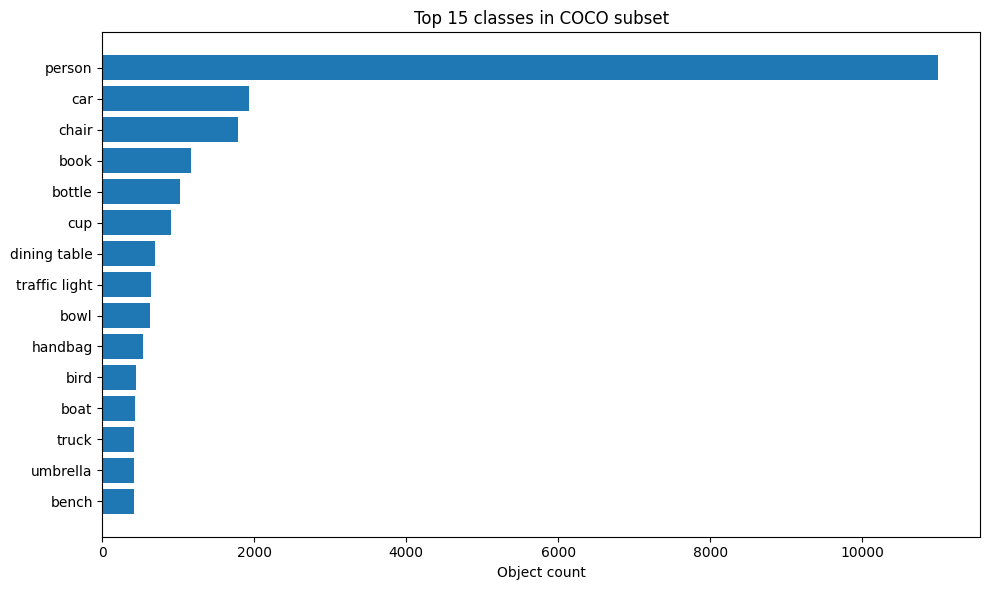

In [25]:
top_classes = class_counts.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_classes["class_name"], top_classes["count"])
plt.gca().invert_yaxis()
plt.xlabel("Object count")
plt.title("Top 15 classes in COCO subset")
plt.tight_layout()
plt.show()